<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/simple-blockies/concept_model_approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random

import numpy as np

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

torch.backends.cudnn.benchmark = True

In [2]:
torch.__version__

'2.6.0+cu124'

In [118]:
CLASSES = ['Healthy', 'OCDegen']
modeltype = 'mobilenet'

ds = 'sick_ones_bendbias_v3_2class_normal'
eval_ds = 'sick_ones_bendbias_v3_2class_variation'

random_state = 42

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
relative_model_path = "two4two_sickones_models_pytorch"
base_path = Path('/content/drive/MyDrive') / relative_model_path
base_path

PosixPath('/content/drive/MyDrive/two4two_sickones_models_pytorch')

In [6]:
# data downloading and dataset utilities

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      with tarfile.open(file_path, "r:gz") as tar:
          tar.extractall(path=cache_dir)
      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)
    elif archive_folder is not None and (Path(cache_dir) / archive_folder).exsists:
      return Path(cache_dir) / archive_folder
    else:
      return Path(cache_dir)

    return Path(file_path)

def load_dataframe(data_dir, dataset):

  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  # df['ill'] = df['ill'].astype(int).astype(str)

  return df

class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None, target_columns=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform
        self.target_columns = target_columns if target_columns is not None else ['spherical', 'ill_spherical', 'bending', 'arm_position']


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        # Load the specified target columns instead of just 'ill'
        targets = self.df.iloc[idx][self.target_columns].values.astype(np.float32)
        targets = torch.tensor(targets)

        if self.transform:
            image = self.transform(image)

        return image, targets

In [7]:
# download datafrom sciebo
data_dir = download_file(url="https://osf.io/download/kexzt/?view_only=adcc520b88cc4ea3b8236c5178ba3ab5",
                         file_name="blockies_datasets.tar.gz",
                         cache_dir='/content/data', # change this if not using Colab
                         extract=True,
                         force_download=False,
                         archive_folder='blockies_datasets')
data_dir

100%|██████████| 1.00G/1.00G [01:28<00:00, 12.1MB/s]


File downloaded to: /content/data/blockies_datasets.tar.gz
File extracted to: /content/data


PosixPath('/content/data/blockies_datasets')

In [8]:
ds_dir = data_dir / ds
eval_ds_dir = data_dir / eval_ds
ds_dir, eval_ds_dir

(PosixPath('/content/data/blockies_datasets/sick_ones_bendbias_v3_2class_normal'),
 PosixPath('/content/data/blockies_datasets/sick_ones_bendbias_v3_2class_variation'))

In [9]:
train_df = load_dataframe(ds_dir, 'train')
val_df = load_dataframe(ds_dir, 'validation')
test_df = load_dataframe(ds_dir, 'test')
eval_df = load_dataframe(eval_ds_dir, 'test')

In [10]:
# regression_target_columns = ['spherical', 'ill_spherical', 'bending', 'arm_position']
regression_target_columns = [
    'spherical', 'ill_spherical', 'bending',  'arm_position',
    'num_diff', 'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw',
    'position_x', 'position_y',
    'obj_color', 'bg_color',
    ]

len(train_df), len(val_df), len(test_df), len(eval_df)

(40000, 1000, 3000, 3000)

In [11]:
#train_df_reduced = load_dataframe(ds_dir, 'train')
train_transforms = T.Compose([
    T.ToTensor()
])

train_dataset_for_norm = ImageDataset(train_df, ds_dir / 'train', transform=train_transforms)
dataloader_for_norm = DataLoader(train_dataset_for_norm, batch_size=100, shuffle=True,
                        num_workers=6, pin_memory=True)

# Initialize variables to calculate mean
mean = torch.zeros(3)  # For RGB channels
total_pixels = 0

# Loop through the dataset
for images, _ in tqdm(dataloader_for_norm):
    # Sum pixel values per channel
    mean += images.sum(dim=[0, 2, 3])
    total_pixels += images.size(0) * images.size(2) * images.size(3)

# Divide by total number of pixels
mean /= total_pixels

print(f"Mean per channel: {mean}")

# Initialize variables for std calculation
std = torch.zeros(3)

# Loop again for standard deviation
for images, _ in tqdm(dataloader_for_norm):
    std += ((images - mean.view(1, 3, 1, 1))**2).sum(dim=[0, 2, 3])

std = torch.sqrt(std / total_pixels)

print(f"Standard Deviation per channel: {std}")

100%|██████████| 400/400 [00:14<00:00, 27.03it/s]


Mean per channel: tensor([0.8068, 0.7830, 0.8005])


100%|██████████| 400/400 [00:14<00:00, 26.99it/s]

Standard Deviation per channel: tensor([0.1093, 0.1136, 0.1029])


In [12]:
# Comprehensive Data Augmentation Pipeline
transform_train = T.Compose([
    # Resize and Crop
    T.RandomResizedCrop(128, scale=(0.8, 1.0)),
    # Flipping
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    # Rotation
    T.RandomRotation(degrees=30),
    # Affine Transformations
    T.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2),
        shear=10
    ),
    # Perspective Transformation
    T.RandomPerspective(distortion_scale=0.5, p=0.5),
    # Color Augmentations
    T.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,
        hue=0.1
    ),
    # Grayscale
    T.RandomGrayscale(p=0.1),
    # Blur
    T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    T.ToTensor(),
    # Random Erasing
    T.RandomErasing(
        p=0.5,
        scale=(0.02, 0.33),
        ratio=(0.3, 3.3)
    ),
    T.Normalize(mean=mean, std=std)
])
# load datasets and dataloaders for Training and Evaluation
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

In [13]:
len(val_df), len(test_df), len(eval_df), len(train_df)

(1000, 3000, 3000, 40000)

In [14]:
# Correcting the data_dir for validation, test, and eval datasets
train_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform, target_columns=regression_target_columns)
print(f"Number of training samples: {len(train_dataset)}")
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                              num_workers=6, pin_memory=True)

train_eval_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform, target_columns=regression_target_columns)
print(f"Number of training eval samples: {len(train_eval_dataset)}")
train_eval_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False,
                                   num_workers=6, pin_memory=True)

val_dataset = ImageDataset(val_df,  ds_dir / 'validation', transform=transform, target_columns=regression_target_columns)
print(f"Number of validation samples: {len(val_dataset)}")
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                            num_workers=6, pin_memory=True)

test_dataset = ImageDataset(test_df,  ds_dir / 'test' , transform=transform, target_columns=regression_target_columns)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                             num_workers=6, pin_memory=True)

eval_dataset = ImageDataset(eval_df,  eval_ds_dir / 'test', transform=transform, target_columns=regression_target_columns)
eval_dataloader = DataLoader(eval_dataset, batch_size=32, shuffle=False,
                             num_workers=6, pin_memory=True)

Number of training samples: 40000
Number of training eval samples: 40000
Number of validation samples: 1000


In [15]:
data_ex = next(iter(train_dataloader))
data_ex[0].shape, data_ex[1].shape

(torch.Size([32, 3, 128, 128]), torch.Size([32, 12]))

Training model

In [16]:
def load_mobilenetv2_regression(num_targets, pretrained=True, checkpoint_path=None):
  """Loads a MobileNetV2 model for regression, optionally loading from a checkpoint.

  Args:
    num_targets: The number of output regression targets.
    pretrained: Whether to load the pre-trained weights.
    checkpoint_path: Path to a checkpoint file to load.

  Returns:
    A MobileNetV2 model configured for regression.
  """
  model = models.mobilenet_v2(weights=None if not pretrained else 'DEFAULT')
  model.classifier[1] = nn.Linear(model.last_channel, num_targets)

  if checkpoint_path:
    try:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu')) # Load to CPU first
        model.load_state_dict(checkpoint)
        print(f"Loaded checkpoint from: {checkpoint_path}")
    except RuntimeError as e:
        print(f"Error loading checkpoint: {e}")
        print("Checkpoint might not match the model architecture. Starting training without loading checkpoint.")

  return model

In [17]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

# Ensure r2_score is imported
from sklearn.metrics import r2_score

def evaluate_model(model, dataloader, criterion, device, num_targets):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0

    all_preds = []
    all_labels = []


    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate R-squared for each target
    r2_scores = []
    for i in range(num_targets):
        r2 = r2_score(all_labels[:, i], all_preds[:, i])
        r2_scores.append(r2)

    print(f"Evaluation Loss: {avg_loss:.4f}")
    for i, r2 in enumerate(r2_scores):
        print(f"R-squared for target {i}: {r2:.4f}")
    return all_preds, avg_loss, r2_scores

def train_model(model, dl_train, dl_val, criterion, optimizer, scheduler, device, checkpoint_path, num_epochs=5, num_targets=4):

  model = model.to(device)

  best_val_loss = sys.float_info.max
  best_epoch = 0

  for epoch in range(num_epochs):

    print(f"Epoch [{epoch+1}/{num_epochs}]")

    # Training phase
    model.train()

    running_train_loss = 0.0

    # Wrap the training dataloader with tqdm for progress visualization
    for inputs, labels in tqdm(dl_train, desc=f"Training Epoch {epoch+1}"):
        # print(inputs.shape, labels.shape, inputs.min(), inputs.max(), inputs.mean())
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track training loss and accuracy
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(dl_train)

    # Validation phase
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in tqdm(dl_val, desc=f"Validation Epoch {epoch+1}"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track validation loss and accuracy
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(dl_val)

    scheduler.step(val_loss)

    # Print epoch results
    print(f"\tTrain Loss: {train_loss:.4f}")
    print(f"\tValidation Loss: {val_loss:.4f}")

    # Checkpointing the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"New best model found at epoch {epoch+1} with validation loss: {val_loss:.4f}")
        best_epoch = epoch + 1
        torch.save(model.state_dict(), checkpoint_path / 'tmp' / 'best_model.pth')  # Save only the model's state_dict

  # To load the best model later:
  model = load_mobilenetv2_regression(num_targets=num_targets,
                                        pretrained=False,
                                        checkpoint_path=checkpoint_path / 'tmp' / 'best_model.pth')
  model.to(device)

  # Evaluate the best model on the validation set
  _, val_loss, val_r2_scores = evaluate_model(model, dl_val, criterion, device, num_targets)


  print(f"Training Run complete! Val loss = {best_val_loss:.4f} | Val R-squared (avg) = {np.mean(val_r2_scores):.4f} | Epoch = {best_epoch}", )
  print("-" * 30)

  return model, val_loss, np.mean(val_r2_scores)

In [18]:
# setup model path
model_path = base_path / ds / f'{modeltype}_regression'
model_path.mkdir(parents=True, exist_ok=True)
print("Model path:", model_path)

# setup checkpoint folders
checkpoint_path = model_path / "torch_mobilenetv2/"
(checkpoint_path / 'tmp').mkdir(parents=True, exist_ok=True)
(checkpoint_path / 'final').mkdir(parents=True, exist_ok=True)

# Define loss function (using MSELoss for regression)
criterion = nn.MSELoss(reduction='sum') # Or nn.L1Loss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

# Define the number of regression targets
num_regression_targets = len(regression_target_columns)

Model path: /content/drive/MyDrive/two4two_sickones_models_pytorch/sick_ones_bendbias_v3_2class_normal/mobilenet_regression


In [19]:
print(f"Shape of train_df: {train_df.shape}")
print(f"Shape of val_df: {val_df.shape}")
print(f"Shape of test_df: {test_df.shape}")
print(f"Shape of eval_df: {eval_df.shape}")

Shape of train_df: (40000, 27)
Shape of val_df: (1000, 27)
Shape of test_df: (3000, 27)
Shape of eval_df: (3000, 27)


In [20]:
# run training
train = False

if train:
  n_runs = 1
  n_epochs = 100

  load_checkpoints = False
  learning_rate = 0.001

  best_val_loss = sys.float_info.max
  for i in range(n_runs):

    set_seed(42 + i)

    print(f"Run {i+1} / {n_runs}")
    print("=" * 30)

    #if i > 0:
    # print('loading previous checkpoint with augmentation')
      #load_checkpoints = True

    #if i >= 0:
      # load previous checkpoint and train without augmentation
    # print('Loading previous checkpoint and training with out augmentation')
      #train_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform)
      #train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                                  # num_workers=6, pin_memory=True)


    # Load the regression model
    model = load_mobilenetv2_regression(num_regression_targets, pretrained=False, checkpoint_path= checkpoint_path / 'final' / 'best_model.pth' if load_checkpoints else None)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.001, amsgrad=True)

    # Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.4, patience=4,
                                                            threshold=0.01, threshold_mode='abs')

  # Train the regression model
    model, val_loss, val_avg_r2 = train_model(model,
                                          train_dataloader, val_dataloader,
                                          criterion, optimizer, scheduler,
                                          device, checkpoint_path,
                                          num_epochs=n_epochs,
                                          num_targets=num_regression_targets)

    # Checkpointing the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"New best model found at Run {i+1} with validation loss: {val_loss:.4f}")
        torch.save(model.state_dict(), checkpoint_path / 'final' / 'best_model.pth')  # Save only the model's state_dict
    print()

  # Load best model:
  model = load_mobilenetv2_regression(num_targets=num_regression_targets,
                          pretrained=False,
                          checkpoint_path=checkpoint_path / 'final' / 'best_model.pth')
  model.to(device)

  # Evaluate the final best model on the validation set
  _, val_loss, val_r2_scores = evaluate_model(model, val_dataloader, criterion, device, num_regression_targets)

  print(f"Training complete! Final Val loss = {val_loss:.4f} | Final Val R-squared (avg) = {np.mean(val_r2_scores):.4f}", )
  print("-" * 30)
else:
  print("Skipping training. Assumes there is a checkpoint to load")

Skipping training. Assumes there is a checkpoint to load


In [21]:
# Ensure the best model is loaded and on the correct device
# This part should be executed after the training section if you haven't already.
model = load_mobilenetv2_regression(num_targets=num_regression_targets,
                          pretrained=False,
                        checkpoint_path=checkpoint_path / 'final' / 'best_model.pth')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval(); # Set the model to evaluation mode

Loaded checkpoint from: /content/drive/MyDrive/two4two_sickones_models_pytorch/sick_ones_bendbias_v3_2class_normal/mobilenet_regression/torch_mobilenetv2/final/best_model.pth


In [22]:
train_preds, _, _ = evaluate_model(model, train_eval_dataloader, criterion, device, num_regression_targets)
test_preds, _, _ = evaluate_model(model, test_dataloader, criterion, device, num_regression_targets)
eval_preds, _, _ = evaluate_model(model, eval_dataloader, criterion, device, num_regression_targets)

Evaluation Loss: 0.1397
R-squared for target 0: 0.9975
R-squared for target 1: 0.9918
R-squared for target 2: 0.9913
R-squared for target 3: 0.9877
R-squared for target 4: 0.9995
R-squared for target 5: 0.0044
R-squared for target 6: 0.9932
R-squared for target 7: 0.9997
R-squared for target 8: 0.9958
R-squared for target 9: 0.9962
R-squared for target 10: 0.9940
R-squared for target 11: 0.9979
Evaluation Loss: 1.4884
R-squared for target 0: 0.9961
R-squared for target 1: 0.9835
R-squared for target 2: 0.9885
R-squared for target 3: 0.9741
R-squared for target 4: 0.9395
R-squared for target 5: 0.0018
R-squared for target 6: 0.9854
R-squared for target 7: 0.9996
R-squared for target 8: 0.9935
R-squared for target 9: 0.9937
R-squared for target 10: 0.9924
R-squared for target 11: 0.9977
Evaluation Loss: 39.8501
R-squared for target 0: 0.8673
R-squared for target 1: 0.6161
R-squared for target 2: 0.4198
R-squared for target 3: -0.0261
R-squared for target 4: 0.2279
R-squared for target 5:

In [166]:
regression_target_columns

['spherical',
 'ill_spherical',
 'bending',
 'arm_position',
 'num_diff',
 'obj_rotation_roll',
 'obj_rotation_pitch',
 'obj_rotation_yaw',
 'position_x',
 'position_y',
 'obj_color',
 'bg_color']

In [23]:
train_preds_df = pd.DataFrame(train_preds, columns=regression_target_columns)
test_preds_df = pd.DataFrame(test_preds, columns=regression_target_columns)
eval_preds_df = pd.DataFrame(eval_preds, columns=regression_target_columns)

new_cols = [f'{f}_pred' for f in regression_target_columns]

train_df[new_cols] = train_preds_df
test_df[new_cols] = test_preds_df
eval_df[new_cols] = eval_preds_df

In [24]:
from xgboost import XGBClassifier

In [26]:
xgb = XGBClassifier(random_state=42)
xgb.fit(train_df[new_cols], train_df['ill'])
xgb.score(train_df[new_cols], train_df['ill'])

0.9873

In [30]:
test_preds = xgb.predict(test_df[new_cols])
test_df['ill_pred'] = test_preds
xgb.score(test_df[new_cols], test_df['ill'])

0.9313333333333333

In [33]:
eval_preds = xgb.predict(eval_df[new_cols])
eval_df['ill_pred'] = eval_preds
xgb.score(eval_df[new_cols], eval_df['ill'])

0.7163333333333334

In [34]:
%pip install shap -q

In [95]:
import shap

In [96]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(test_df[regression_target_columns])

In [97]:
type(shap_values)

shap._explanation.Explanation

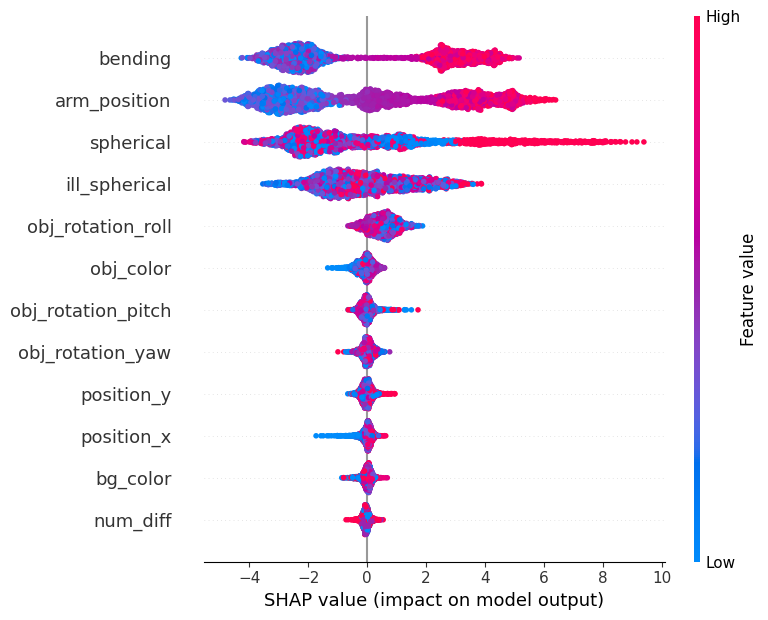

In [98]:
# Global explanation with SHAP
shap.summary_plot(shap_values, test_df[regression_target_columns])

In [99]:
# Local Explanations with SHAP

In [100]:
# local at incorrect samples
incorr_rows = test_df['ill_pred'] != test_df['ill']
sample = test_df[incorr_rows].sample(1)
sample

,obj_name,labeling_error,spherical,ill,ill_chars,ill_spherical,num_diff,bending,obj_rotation_roll,obj_rotation_pitch,...,arm_position_pred,num_diff_pred,obj_rotation_roll_pred,obj_rotation_pitch_pred,obj_rotation_yaw_pred,position_x_pred,position_y_pred,obj_color_pred,bg_color_pred,ill_pred
614,peaky,False,0.996695,1,"[stretchy, high_sphere_diff, med_bend]",0.419566,1,0.177347,0.021176,-0.05596,...,0.480229,0.98539,0.000063,-0.075742,-1.361388,-0.0643,-0.63396,0.536986,0.926627,0


,ill,ill_pred,ill_chars,spherical,ill_spherical,bending,arm_position,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,obj_color,obj_color_rgba,bg_color,bg_color_rgba,id
614,1,0,"[stretchy, high_sphere_diff, med_bend]",0.996695,0.419566,0.177347,0.505199,0.021176,-0.05596,-1.377339,False,-0.047268,-0.637351,0.620791,"[0.324048802033206, 0.15765194657949902, 0.169...",0.927491,"[0.805722963047058, 0.259813136258823, 0.23056...",58cf561b-800b-44e3-82fe-aae8774c6453


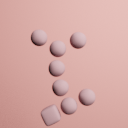

In [111]:
cols = ['ill', 'ill_pred', 'ill_chars', 'spherical',
       'ill_spherical', 'bending', 'arm_position', 'obj_rotation_roll',
       'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr', 'position_x',
       'position_y', 'obj_color', 'obj_color_rgba', 'bg_color',
       'bg_color_rgba', 'id']
display(sample[cols])
path = ds_dir / 'test' / sample['filename'].iloc[0]
path
img = Image.open(path).convert('RGB')
img

Prediction: 0, True: 1


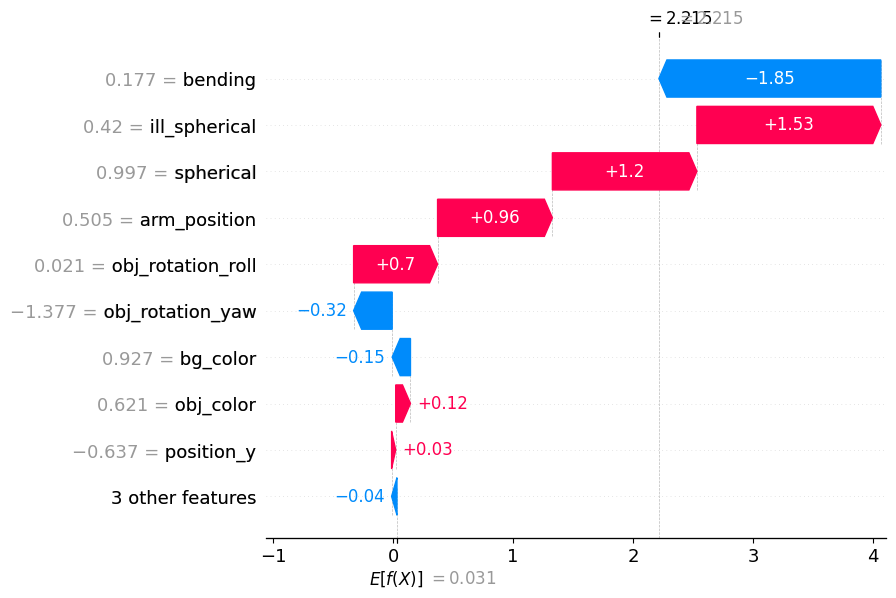

In [102]:
pred = sample['ill_pred'].values[0]
true = sample['ill'].values[0]
idx = sample.index[0]
print(f"Prediction: {pred}, True: {true}")
shap.waterfall_plot(shap_values[idx, :])

In [103]:
n_features = 4
sv = shap_values.values[idx, :]
abs_shap = np.abs(sv)

feature_importance = pd.Series(abs_shap, index=regression_target_columns)
sorted_features = feature_importance.sort_values(ascending=False)
top_features = sorted_features.head(n_features).index.tolist()
top_features

['bending', 'ill_spherical', 'spherical', 'arm_position']

## generate regression LRP



In [104]:
%pip install zennit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.3 MB/s eta 0:00:00


In [105]:

from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat, EpsilonGammaBox

In [122]:
targets = torch.tensor([regression_target_columns.index(f) for f in top_features])
targets = F.one_hot(targets, num_classes=len(regression_target_columns)).float().to('cpu')
targets

tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [124]:
# only works on cpu for some reason?  need to further troubleshoot
model.to('cpu')

# the ZBox rule needs the lowest and highest values, which are here for
# ImageNet 0. and 1. with a different normalization for each channel
transform_norm = T.Compose([
    T.Normalize(mean=mean, std=std)
])
low, high = transform_norm(torch.tensor([[[[[0.]]] * 3], [[[[1.]]] * 3]]))

with Gradient(model=model, composite=EpsilonGammaBox(low=low, high=high, canonizers=[ResNetCanonizer()])) as attributor:
  inp = [transform(img) for i in range(len(top_features))]
  inp = torch.stack(inp)
  inp = inp.to('cpu')
  output, attribution = attributor(inp, targets)

# add model back to gpu (in case used again somewhere else)
model = model.to(device)

In [132]:
attribution.shape, attribution.mean(axis=(1, 2, 3))

(torch.Size([4, 3, 128, 128]), tensor([0.0011, 0.0015, 0.0028, 0.0018]))

In [126]:
def plot_lrp(img, attribution, ax):
  relevance = attribution.sum(0)
  vmax = relevance.abs().max()
  ax.imshow(img)
  ax.imshow(relevance, cmap='bwr', vmin=-vmax, vmax=vmax, alpha=0.75)
  ax.axis('off')

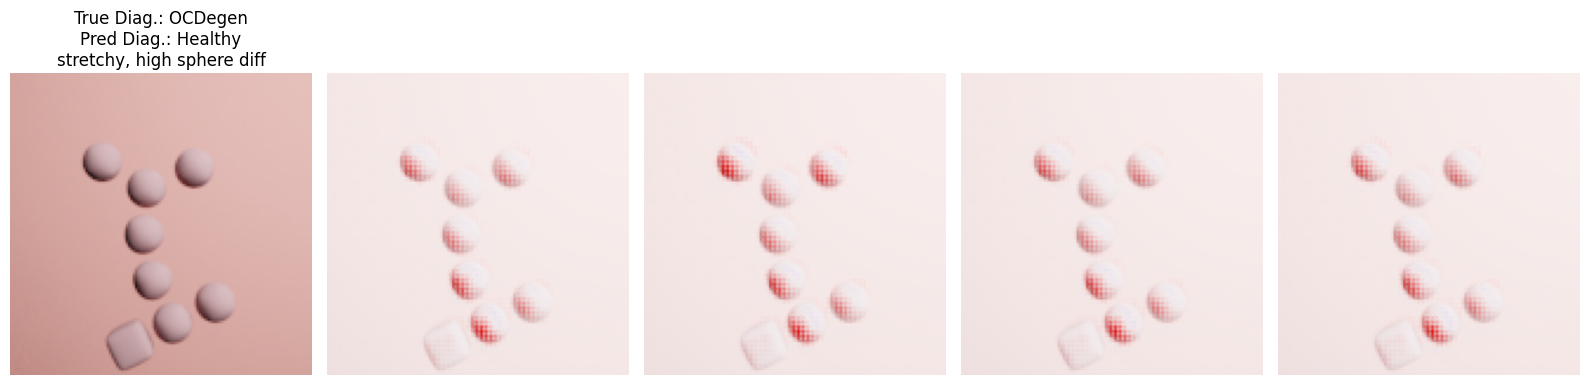

In [128]:
fig, axes = plt.subplots(1, 5, figsize=(16, 8))
axes = axes.flatten()

true_label = CLASSES[true]
pred_label = CLASSES[pred]
ill_chars = [i for i in sample.iloc[0]["ill_chars"] if i in ['high_sphere_diff', 'high_bend', 'mutation_mainbones', 'stretchy']]
ill_chars = ', '.join(ill_chars).replace('_', ' ')


ax = axes[0]
ax.imshow(img)
ax.axis('off')
ax.set_title('Original Image')
ax.set_title(f'True Diag.: {true_label}\nPred Diag.: {pred_label}\n{ill_chars}')

for i, (hm, ax) in enumerate(zip(attribution, axes[1:])):
  plot_lrp(np.array(img), hm, ax)

plt.tight_layout()
plt.show()

## Grad CAM

In [135]:
%pip install grad-cam -q

In [136]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [151]:
def display_blocky(img, ax=None):
    """
    Displays a single blocky image.

    Parameters:
    img (numpy.ndarray): The image to display.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    else:
        fig = ax.figure

    ax.clear()
    ax.imshow(img)
    ax.axis('off')

In [146]:
target_idxs = [regression_target_columns.index(f) for f in top_features]
target_idxs

[2, 1, 0, 3]

In [150]:
target_layers = [model.features[-1]] # last conv layer of MobileNet

imgs_tensor = torch.stack([transform(img) for i in range(len(top_features))]).to(torch.double).to(device)

targets = [ClassifierOutputTarget(i) for i in target_idxs]

cam_explainer = GradCAM(model=model, target_layers=target_layers)
heatmaps = cam_explainer(input_tensor=imgs_tensor, targets=targets)

In [165]:
regression_target_columns

['spherical',
 'ill_spherical',
 'bending',
 'arm_position',
 'num_diff',
 'obj_rotation_roll',
 'obj_rotation_pitch',
 'obj_rotation_yaw',
 'position_x',
 'position_y',
 'obj_color',
 'bg_color']

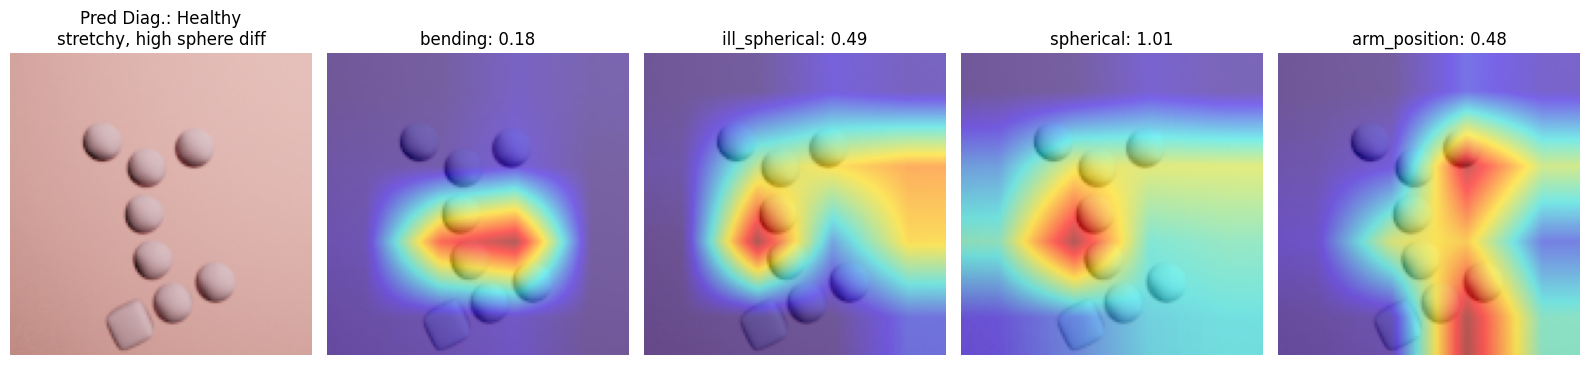

In [164]:
fig, axes = plt.subplots(1, 5, figsize=(16, 8))
axes = axes.flatten()

true_label = CLASSES[true]
pred_label = CLASSES[pred]
ill_chars = [i for i in sample.iloc[0]["ill_chars"] if i in ['high_sphere_diff', 'high_bend', 'mutation_mainbones', 'stretchy']]
ill_chars = ', '.join(ill_chars).replace('_', ' ')


ax = axes[0]
ax.imshow(img)
ax.axis('off')
ax.set_title('Original Image')
ax.set_title(f'Pred Diag.: {pred_label}\n{ill_chars}')


for i, (hm, ax) in enumerate(zip(heatmaps, axes[1:])):
    visualization = show_cam_on_image(np.array(img)/255, hm, use_rgb=True)
    display_blocky(visualization, ax)
    topf = top_features[i]
    feat_pred = sample[f'{topf}_pred'].values[0]
    ax.set_title(f'{topf}: {feat_pred:.2f}')
plt.tight_layout()
plt.show()

Prediction: 0, True: 1


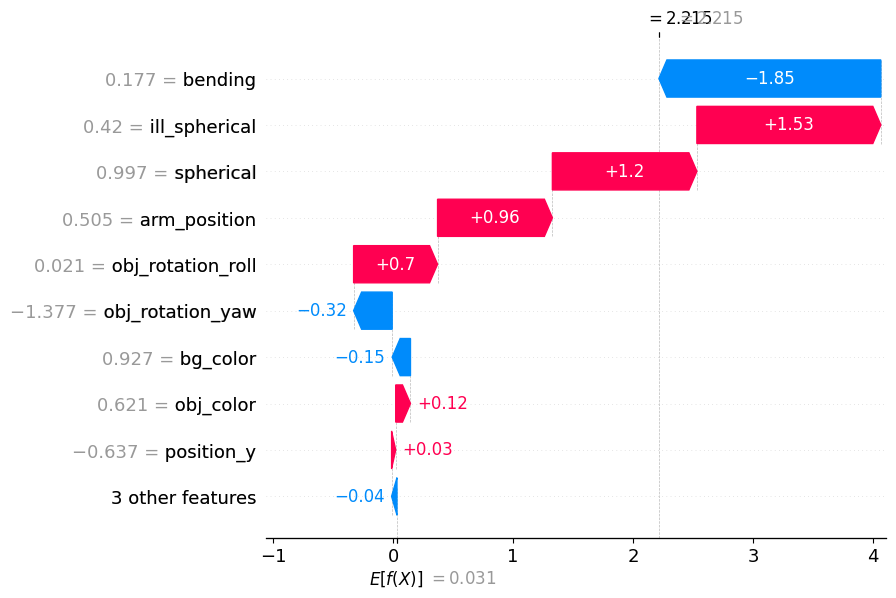

In [162]:
pred = sample['ill_pred'].values[0]
true = sample['ill'].values[0]
idx = sample.index[0]
print(f"Prediction: {pred}, True: {true}")
shap.waterfall_plot(shap_values[idx, :])